# Tech Stock Analysis and Prediction
## Notebook 2: Preprocessing

**Goal:** Prepare NVDA stock data for modeling 

**Input:** Cleaned data from EDA notebook → `data/cleaned_data.csv`

**Output:** Preprocessed train and test sets → `data/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as  plt 

c:\Users\LENOVO\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


#  Loading Data

In [2]:
# load cleaned data
df = pd.read_csv(r'../data/cleaned_data.csv')
df['date'] = pd.to_datetime(df['date'])
print(df.shape)
print(df.head())

(9944, 6)
        date Stock  Adj Close   Returns  Rolling Std    Growth
0 2018-02-02  aapl  37.552658 -0.043390     0.009253  1.000000
1 2018-02-05  aapl  36.614433 -0.024984     0.013041  0.975016
2 2018-02-06  aapl  38.144608  0.041792     0.013726  1.015763
3 2018-02-07  aapl  37.328030 -0.021407     0.016772  0.994018
4 2018-02-08  aapl  36.300903 -0.027516     0.017235  0.966667


In [3]:
nvda = df[df['Stock'] == 'nvda'].copy()
nvda = nvda.sort_values('date').reset_index(drop=True)
print(nvda.shape)
print(nvda.head())

(1989, 6)
        date Stock  Adj Close   Returns  Rolling Std    Growth
0 2018-02-01  nvda   5.945884 -0.021562     0.209901  1.000000
1 2018-02-02  nvda   5.773318 -0.029023     0.019804  0.970977
2 2018-02-05  nvda   5.283309 -0.084875     0.016829  0.888566
3 2018-02-06  nvda   5.577019  0.055592     0.025778  0.937963
4 2018-02-07  nvda   5.656625  0.014274     0.028434  0.951351


In [4]:
nvda.describe().T

,count,mean,min,25%,50%,75%,max,std
date,1989,2022-01-14 00:39:05.701357312,2018-02-01 00:00:00,2020-01-24 00:00:00,2022-01-12 00:00:00,2024-01-05 00:00:00,2025-12-30 00:00:00,NaN
Adj Close,1989.0,44.773591,3.150568,6.564618,17.785475,50.376499,207.028473,54.136069
Returns,1989.0,0.00225,-0.187559,-0.015181,0.002769,0.019754,0.243696,0.032416
Rolling Std,1989.0,0.03021,0.010865,0.021059,0.026418,0.037347,0.209901,0.012887
Growth,1989.0,7.530182,0.529874,1.104061,2.991225,8.472499,34.818786,9.104797


# Pre-Feature Engineering Data Validation

Before creating features for modeling, we must validate the dataset to ensure:
- Data integrity (no nulls, duplicates, or corrupted values)
- Proper temporal ordering (critical for time series)
- Target variable quality (distribution, outliers)`
- No data leakage (features don't contain future information)

These checks prevent propagating data quality issues into our features and models.

## 1. Data Integrity Checking

Verifying that the dataset has the expected structure and no missing or duplicate record in it.

In [5]:
# Dataset shape
print(" Dataset shape:",nvda.shape)
print(nvda.shape[0]," rows (trading days)")
print(nvda.shape[1],"columns (features)\n")

# Check for duplicates
duplicates = nvda.duplicated().sum()
print(f" Duplicate rows: {duplicates}")
if duplicates == 0:
    print("No duplicates found \n")
else:
    print(f"{duplicates} duplicates detected!\n")

# Check for missing values
print(" Missing values per column:")
nulls = nvda.isnull().sum()
print(nulls)
# Date range
print(f"Date range: {nvda['date'].min()} to {nvda['date'].max()}")
date_span = (nvda['date'].max() - nvda['date'].min()).days
print(f"Covers {date_span} days (~{date_span/365:.1f} years)\n")


 Dataset shape: (1989, 6)
1989  rows (trading days)
6 columns (features)

 Duplicate rows: 0
No duplicates found 

 Missing values per column:
date           0
Stock          0
Adj Close      0
Returns        0
Rolling Std    0
Growth         0
dtype: int64
Date range: 2018-02-01 00:00:00 to 2025-12-30 00:00:00
Covers 2889 days (~7.9 years)



## 2. Temporal Continuity Checking

Time series models require chronologically ordered data with no unexpected gaps that could disrupt sequential patterns.

In [6]:
# Check if dates are sorted
is_sorted = nvda['date'].is_monotonic_increasing
print(f" Dates chronologically sorted: {is_sorted}")
if is_sorted:
    print("   Data is properly ordered \n")
else:
    print("   WARNING: Dates are not sorted\n")

# Check for unusual gaps (more than 5 business days)
nvda_temp = nvda.copy()
nvda_temp['date_diff'] = nvda_temp['date'].diff()
gaps = nvda_temp[nvda_temp['date_diff'] > pd.Timedelta(days=7)]

print(f" Date gaps > 7 days: {len(gaps)}")
if len(gaps) == 0:
    print("   No unusual gaps found \n")
else:
    print(f"   Found {len(gaps)} gaps (holidays/weekends expected)\n")
    print(gaps[['date', 'date_diff']].head())
    print()

 Dates chronologically sorted: True
   Data is properly ordered 

 Date gaps > 7 days: 0
   No unusual gaps found 



## 3. Target Variable Analysis

Examining the distribution and characteristics of daily returns to understand prediction difficulty and identify extreme events.

 Returns statistics:
count    1989.000000
mean        0.002250
std         0.032416
min        -0.187559
25%        -0.015181
50%         0.002769
75%         0.019754
max         0.243696
Name: Returns, dtype: float64

 Extreme daily returns (>10%): 18
   Dates with extreme moves:
           date   Returns
201  2018-11-16 -0.187559
532  2020-03-16 -0.184521
1755 2025-01-27 -0.169682
247  2019-01-28 -0.138246
530  2020-03-12 -0.122368
202  2018-11-19 -0.119990
1563 2024-04-19 -0.100046
547  2020-04-06  0.100406
533  2020-03-17  0.106262
531  2020-03-13  0.113402
947  2021-11-04  0.120423
1633 2024-07-31  0.128121
1273 2023-02-23  0.140214
1203 2022-11-10  0.143293
1523 2024-02-22  0.164009
538  2020-03-24  0.171564
1806 2025-04-09  0.187227
1337 2023-05-25  0.243696



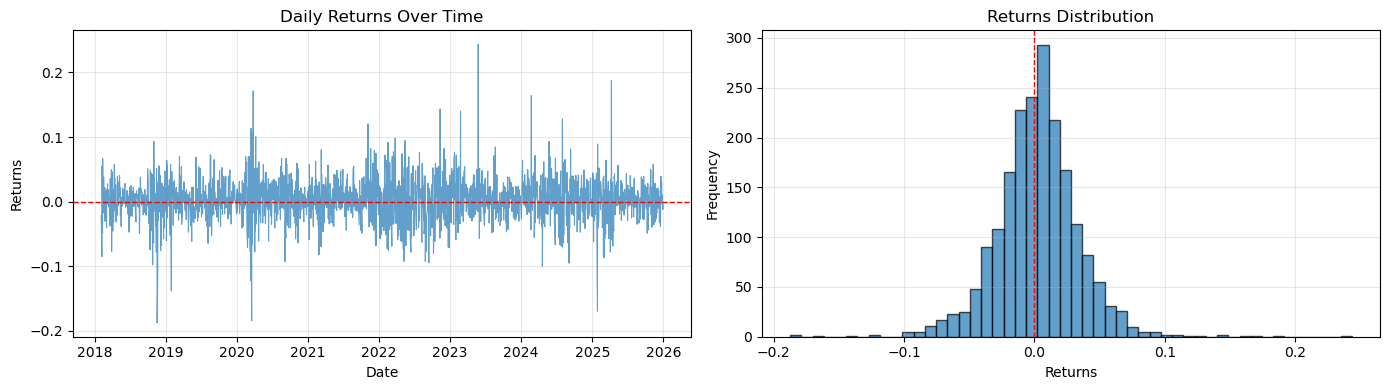

 Visualization complete



In [7]:

# Returns statistics
print(" Returns statistics:")
print(nvda['Returns'].describe())
print()

# Check for extreme outliers (>10% daily moves)
extreme_returns = nvda[abs(nvda['Returns']) > 0.10]
print(f" Extreme daily returns (>10%): {len(extreme_returns)}")
if len(extreme_returns) > 0:
    print("   Dates with extreme moves:")
    print(extreme_returns[['date', 'Returns']].sort_values('Returns'))
    print()
else:
    print("   No extreme outliers\n")

# Visualize returns over time and distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Returns time series
axes[0].plot(nvda['date'], nvda['Returns'], alpha=0.7, linewidth=0.8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Daily Returns Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Returns')
axes[0].grid(alpha=0.3)

# Returns distribution
axes[1].hist(nvda['Returns'], bins=50, alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Returns Distribution')
axes[1].set_xlabel('Returns')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" Visualization complete\n")

## 4. Feature Leakage Checking

Ensuring existing columns like Growth don't contain future information that would invalidate predictions.

In [8]:
# Check Growth column logic
print("Examining 'Growth' column (first 10 rows):")
print(nvda[['date', 'Adj Close', 'Returns', 'Growth']].head(10))
print()

# Verify Growth is cumulative from start (not future-looking)
expected_growth = (1 + nvda['Returns']).cumprod()
growth_match = np.allclose(nvda['Growth'], expected_growth, rtol=1e-5)

print(f"Growth column is cumulative product: {growth_match}")
if growth_match:
    print("  No leakage detected \n")
else:
    print("  WARNING: Growth calculation may be incorrect \n")

Examining 'Growth' column (first 10 rows):
        date  Adj Close   Returns    Growth
0 2018-02-01   5.945884 -0.021562  1.000000
1 2018-02-02   5.773318 -0.029023  0.970977
2 2018-02-05   5.283309 -0.084875  0.888566
3 2018-02-06   5.577019  0.055592  0.937963
4 2018-02-07   5.656625  0.014274  0.951351
5 2018-02-08   5.377751 -0.049300  0.904449
6 2018-02-09   5.737717  0.066936  0.964990
7 2018-02-12   5.637588 -0.017451  0.948150
8 2018-02-13   5.751316  0.020173  0.967277
9 2018-02-14   5.968630  0.037785  1.003826

Growth column is cumulative product: False



## 5. Stationarity Visual Check

Stock prices trend over time (non-stationary), while returns should fluctuate around zero (stationary). Models perform better on stationary data.

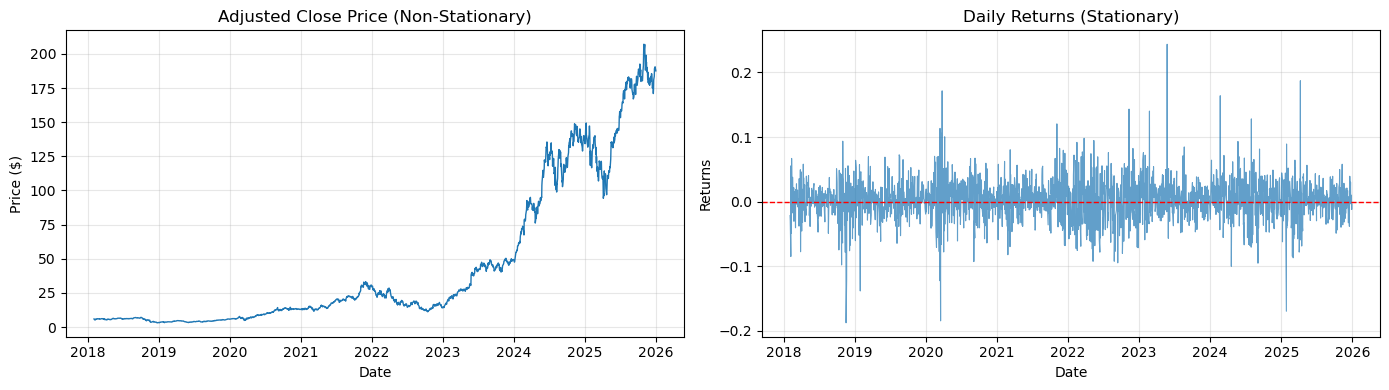

Returns exhibit mean-reverting behavior around zero
Suitable for modeling


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Price over time (non-stationary)
axes[0].plot(nvda['date'], nvda['Adj Close'], linewidth=1)
axes[0].set_title('Adjusted Close Price (Non-Stationary)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price ($)')
axes[0].grid(alpha=0.3)

# Returns over time (should be stationary)
axes[1].plot(nvda['date'], nvda['Returns'], alpha=0.7, linewidth=0.8)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Daily Returns (Stationary)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Returns')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Returns exhibit mean-reverting behavior around zero")
print("Suitable for modeling")


All validation checks passed successfully:
-  No missing values or duplicates
-  Dates properly ordered with no unusual gaps
-  Returns distribution shows expected volatility patterns
-  No data leakage in existing features
-  Returns are stationary (suitable for prediction)

The dataset is clean and ready for feature engineering.

In [10]:
nvda.to_csv(r'../data/nvda_cleaned.csv',index=False)
print("data saved successfully")

data saved successfully
